In [1]:
# Automatically locate the project's root directory
from crispdm.common.path_service_common import find_project_root

# Data manipulation and analysis using DataFrames
import pandas as pd

# Statistical data visualization built on top of matplotlib
import seaborn as sns

# Parsing and handling JSON data structures
import json

# Creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Numerical computing and support for large, multi-dimensional arrays
import numpy as np

# Fitting and working with statistical distributions (Normal, Skew-Normal, Gamma)
from scipy.stats import norm, skewnorm, gamma

# Object-oriented file system paths management
import pathlib

from IPython.display import display

# Reading and writing YAML configuration files
import yaml

In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260521_095921" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "clustering" / "ms_sec_inc_pre" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase5_evaluation_and_interpretation"

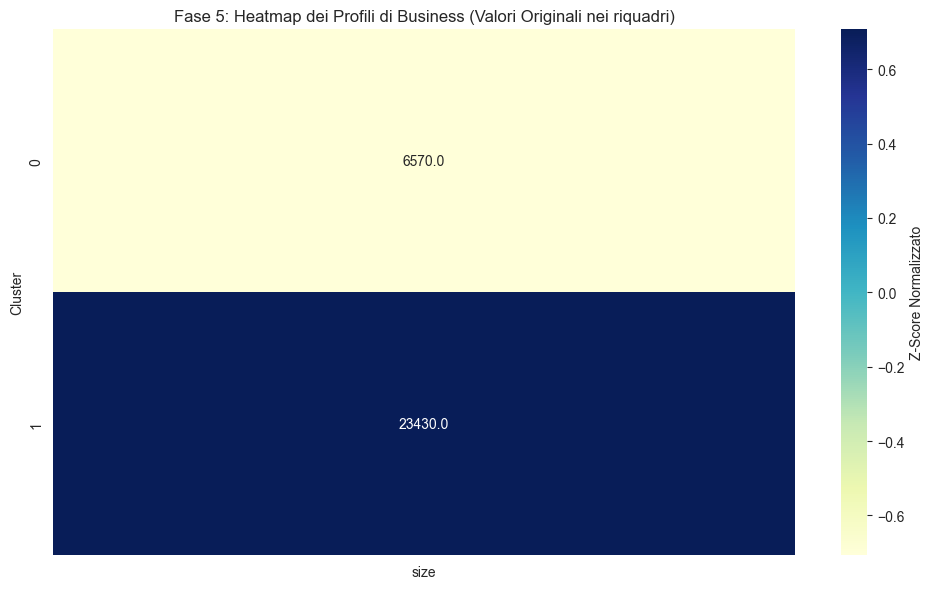

RELAZIONE FASE 5: VALUTAZIONE DI BUSINESS E RACCOMANDAZIONI
Identità dei Cluster (Denormalizzata per il Dominio Aziendale):


,Cluster,size
0,0,6570
1,1,23430



Audit di Processo:
- Analisi SOC / Matrice di Confusione applicata ai target di sicurezza/incidente completata.

Raccomandazioni Strategiche (Pronti per il Deployment - Fase 6):
 - OVERALL_RECOMMENDATION: Deployment of unknown is NOT recommended. Address the following barriers before proceeding: ARI threshold not met: 0.000 < 0.050. Clusters show weak alignment with known ground truth.
 - WINNING_MODEL: unknown
 - DEPLOYMENT_CONSIDERATIONS: ['If deploying, ensure cluster labels are mapped to human-readable categories.', 'Consider using the winning model as a triage pre-filter before supervised ML.', "Test set ('reserved — not used in unsupervised clustering phase') is not used in unsupervised clustering; reserve for supervised model validation.", 'Document cluster characterisation rules (top-10 features) for SOC analysts.', 'Set up version control for the pipeline configuration and transformer serialisation.']
 - MONITORING_SUGGESTIONS: ['Track cluster distribution over time for drift

In [3]:
# =============================================================================
# DEFINIZIONE PERCORSO FASE
# =============================================================================


# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
path_profiles_n2 = base_phase_path / "5.1.interpretation.kmeans_n2_profiles.json"
path_soc_confusion = base_phase_path / "5.2.business_evaluation.soc_confusion_matrices.json"
path_recommendations = base_phase_path / "5.4.decision_making.recommendations.json"

with open(path_profiles_n2, 'r', encoding='utf-8') as f:
    cluster_profiles = json.load(f)

with open(path_soc_confusion, 'r', encoding='utf-8') as f:
    soc_eval = json.load(f)

with open(path_recommendations, 'r', encoding='utf-8') as f:
    recommendations = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estraiamo i centroidi denormalizzati (profili di business reali)
profile_data = []
for cluster_id, metrics in cluster_profiles.items():
    row = {"Cluster": cluster_id}
    # Assumiamo che dentro metrics ci siano le medie delle feature reali
    for feature, value in metrics.items():
        if isinstance(value, (int, float)):
            row[feature] = round(value, 2)
    profile_data.append(row)

df_business_profiles = pd.DataFrame(profile_data)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica
# =============================================================================
# Usiamo una Heatmap per visualizzare rapidamente cosa caratterizza ogni cluster
plt.figure(figsize=(10, 6))
# Rimuoviamo la colonna 'Cluster' per la heatmap
df_heatmap = df_business_profiles.set_index("Cluster")
# Scaliamo colonna per colonna (solo per la visualizzazione) per evidenziare i contrasti
sns.heatmap(df_heatmap.apply(lambda x: (x-x.mean())/x.std()), annot=df_heatmap.values, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Z-Score Normalizzato'})
plt.title("Fase 5: Heatmap dei Profili di Business (Valori Originali nei riquadri)")
plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================
print("=========================================================================")
print("RELAZIONE FASE 5: VALUTAZIONE DI BUSINESS E RACCOMANDAZIONI")
print("=========================================================================")
print("Identità dei Cluster (Denormalizzata per il Dominio Aziendale):")
display(df_business_profiles)

print("\nAudit di Processo:")
print("- Analisi SOC / Matrice di Confusione applicata ai target di sicurezza/incidente completata.")

print("\nRaccomandazioni Strategiche (Pronti per il Deployment - Fase 6):")
# Stampa sicura in caso le raccomandazioni siano in liste o dizionari
if isinstance(recommendations, dict):
    for k, v in recommendations.items():
        print(f" - {k.upper()}: {v}")
else:
    print(f" - {recommendations}")
print("=========================================================================")